In [3]:
# Importing all the necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Loading the dataset
df = pd.read_csv(r'C:\Depression_ML\data\raw\mental_health_risk_dataset (1).csv')
df.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [5]:
df.tail()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
24995,36,Female,Single,Bachelor,Unemployed,3.3,8.4,4.6,4,3,...,1,2,5,1,0,0,1,0,0,0
24996,49,Female,Divorced,Master,Student,4.7,6.6,2.1,6,6,...,2,8,7,1,1,0,0,0,1,1
24997,35,Female,Married,PhD,Self-Employed,4.0,12.8,11.3,4,10,...,7,3,3,4,1,0,1,0,1,2
24998,44,Male,Divorced,High School,Student,5.1,2.0,3.0,5,4,...,7,7,8,1,0,1,1,0,1,0
24999,19,Male,Single,Master,Self-Employed,9.4,14.3,11.8,10,1,...,9,3,5,1,1,0,1,0,1,1


#### EDA (Exploratory Data Analysis)

In [6]:
# Checking the Dataset shape
df.shape
# 25000 rows
# 25 columns in the dataset

(25000, 25)

In [7]:
# understanding the Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  str    
 2   marital_status                    25000 non-null  str    
 3   education_level                   25000 non-null  str    
 4   employment_status                 25000 non-null  str    
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  financial_stres

In [8]:
# Separating the numerical and the categorical columns 

numerical_columns = df.select_dtypes(include = ['int64','float64'])
numerical_columns

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,8.6,2.8,9.6,7,10,3,7,8,40,...,4,8,8,3,1,0,1,1,1,1
1,47,4.5,2.7,3.0,10,6,9,1,10,31,...,7,4,9,3,0,0,0,0,0,0
2,56,3.1,14.1,7.2,10,5,2,4,7,28,...,3,1,4,2,1,1,1,1,1,2
3,59,7.0,0.5,10.3,2,10,4,8,7,63,...,8,5,2,5,1,1,0,1,1,2
4,58,5.1,2.5,1.2,8,1,8,8,3,28,...,8,3,3,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,36,3.3,8.4,4.6,4,3,2,6,3,26,...,1,2,5,1,0,0,1,0,0,0
24996,49,4.7,6.6,2.1,6,6,1,7,7,60,...,2,8,7,1,1,0,0,0,1,1
24997,35,4.0,12.8,11.3,4,10,10,2,7,56,...,7,3,3,4,1,0,1,0,1,2
24998,44,5.1,2.0,3.0,5,4,6,1,5,36,...,7,7,8,1,0,1,1,0,1,0


In [9]:
# Now for the categorical columns
categorical_column = df.select_dtypes(include = ['str'])
categorical_column

,gender,marital_status,education_level,employment_status
0,Other,Single,Bachelor,Unemployed
1,Male,Single,Bachelor,Unemployed
2,Female,Divorced,Bachelor,Student
3,Other,Married,Bachelor,Employed
4,Male,Single,High School,Self-Employed
...,...,...,...,...
24995,Female,Single,Bachelor,Unemployed
24996,Female,Divorced,Master,Student
24997,Female,Married,PhD,Self-Employed
24998,Male,Divorced,High School,Student


In [10]:
df.describe()

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,...,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,...,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [11]:
df.describe(include = 'str')

,gender,marital_status,education_level,employment_status
count,25000,25000,25000,25000
unique,3,3,4,4
top,Male,Divorced,High School,Employed
freq,8438,8457,6356,6293


In [12]:
for col in categorical_column:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      8438
Female    8300
Other     8262
Name: count, dtype: int64

marital_status
marital_status
Divorced    8457
Married     8382
Single      8161
Name: count, dtype: int64

education_level
education_level
High School    6356
Bachelor       6261
Master         6195
PhD            6188
Name: count, dtype: int64

employment_status
employment_status
Employed         6293
Self-Employed    6245
Unemployed       6235
Student          6227
Name: count, dtype: int64


In [13]:
# Checking is there any missing values in it or not
df.isnull().sum()

# So from this we have seen that there are no missing values in it

age                                 0
gender                              0
marital_status                      0
education_level                     0
employment_status                   0
sleep_hours                         0
physical_activity_hours_per_week    0
screen_time_hours_per_day           0
social_support_score                0
work_stress_level                   0
academic_pressure_level             0
job_satisfaction_score              0
financial_stress_level              0
working_hours_per_week              0
anxiety_score                       0
depression_score                    0
stress_level                        0
mood_swings_frequency               0
concentration_difficulty_level      0
panic_attack_history                0
family_history_mental_illness       0
previous_mental_health_diagnosis    0
therapy_history                     0
substance_use                       0
mental_health_risk                  0
dtype: int64

In [14]:
# Checking missing value with the percentage 

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending = False)

age                                 0.0
gender                              0.0
marital_status                      0.0
education_level                     0.0
employment_status                   0.0
sleep_hours                         0.0
physical_activity_hours_per_week    0.0
screen_time_hours_per_day           0.0
social_support_score                0.0
work_stress_level                   0.0
academic_pressure_level             0.0
job_satisfaction_score              0.0
financial_stress_level              0.0
working_hours_per_week              0.0
anxiety_score                       0.0
depression_score                    0.0
stress_level                        0.0
mood_swings_frequency               0.0
concentration_difficulty_level      0.0
panic_attack_history                0.0
family_history_mental_illness       0.0
previous_mental_health_diagnosis    0.0
therapy_history                     0.0
substance_use                       0.0
mental_health_risk                  0.0


In [15]:
# Now checking the duplicated vlaues in the dataset
df.duplicated().sum()

np.int64(0)

In [16]:
# Checking the unique values in the dataset
df.nunique()

age                                  43
gender                                3
marital_status                        3
education_level                       4
employment_status                     4
sleep_hours                          71
physical_activity_hours_per_week    151
screen_time_hours_per_day           111
social_support_score                 10
work_stress_level                    10
academic_pressure_level              10
job_satisfaction_score               10
financial_stress_level               10
working_hours_per_week               51
anxiety_score                        10
depression_score                     10
stress_level                         10
mood_swings_frequency                10
concentration_difficulty_level       10
panic_attack_history                  2
family_history_mental_illness         2
previous_mental_health_diagnosis      2
therapy_history                       2
substance_use                         2
mental_health_risk                    3


In [17]:
df['mental_health_risk'].value_counts(normalize=True) * 100

mental_health_risk
1    47.292
0    37.428
2    15.280
Name: proportion, dtype: float64

In [18]:
binary_columns = [
    'sleep_hours',
    'physical_activity_hours_per_week',
    'screen_time_hours_per_day',
    'social_support_score',
    'work_stress_level',
    'academic_pressure_level',
    'job_satisfaction_score',
    'financial_stress_level',
    'working_hours_per_week',
    'anxiety_score',
    'depression_score',
    'stress_level',
    'mood_swings_frequency',
    'concentration_difficulty_level',
    'panic_attack_history',
    'family_history_mental_illness',
    'previous_mental_health_diagnosis',
    'therapy_history',
    'substance_use',
    'mental_health_risk'
]

for col in binary_columns:
    print(f'\n{col}')
    print(df[col].value_counts())


sleep_hours
sleep_hours
5.1     395
6.1     392
4.5     391
9.3     391
9.5     391
       ... 
5.4     326
8.7     326
4.4     320
10.0    167
3.0     152
Name: count, Length: 71, dtype: int64

physical_activity_hours_per_week
physical_activity_hours_per_week
4.3     196
9.1     196
2.5     194
4.5     194
3.1     194
       ... 
12.2    141
4.7     140
7.2     132
15.0     87
0.0      69
Name: count, Length: 151, dtype: int64

screen_time_hours_per_day
screen_time_hours_per_day
1.1     264
3.7     263
7.7     260
8.7     258
5.3     257
       ... 
1.5     194
11.9    193
3.5     189
1.0     111
12.0    101
Name: count, Length: 111, dtype: int64

social_support_score
social_support_score
10    2605
2     2546
4     2521
9     2508
6     2498
3     2490
1     2486
8     2472
5     2463
7     2411
Name: count, dtype: int64

work_stress_level
work_stress_level
6     2575
8     2533
10    2506
7     2504
5     2493
4     2491
9     2483
3     2479
2     2476
1     2460
Name: count, dtyp

In [19]:
# Numerical Columns 
numerical_features = [
    'age',
    'social_support_score',
    'work_stress_level',
    'academic_pressure_level',
    'job_satisfaction_score',
    'financial_stress_level',
    'working_hours_per_week',
    'anxiety_score',
    'depression_score',
    'stress_level',
    'mood_swings_frequency',
    'concentration_difficulty_level',
    'panic_attack_history',
    'family_history_mental_illness',
    'previous_mental_health_diagnosis',
    'therapy_history',
    'substance_use',
]

# Categorical features
categorical_features = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status'
]

# Binary Features
binary_features = [
    'sleep_hours',
    'physical_activity_hours_per_week',
    'screen_time_hours_per_day'
]

# Target feature
target_feature = [
    'mental_health_risk'
]

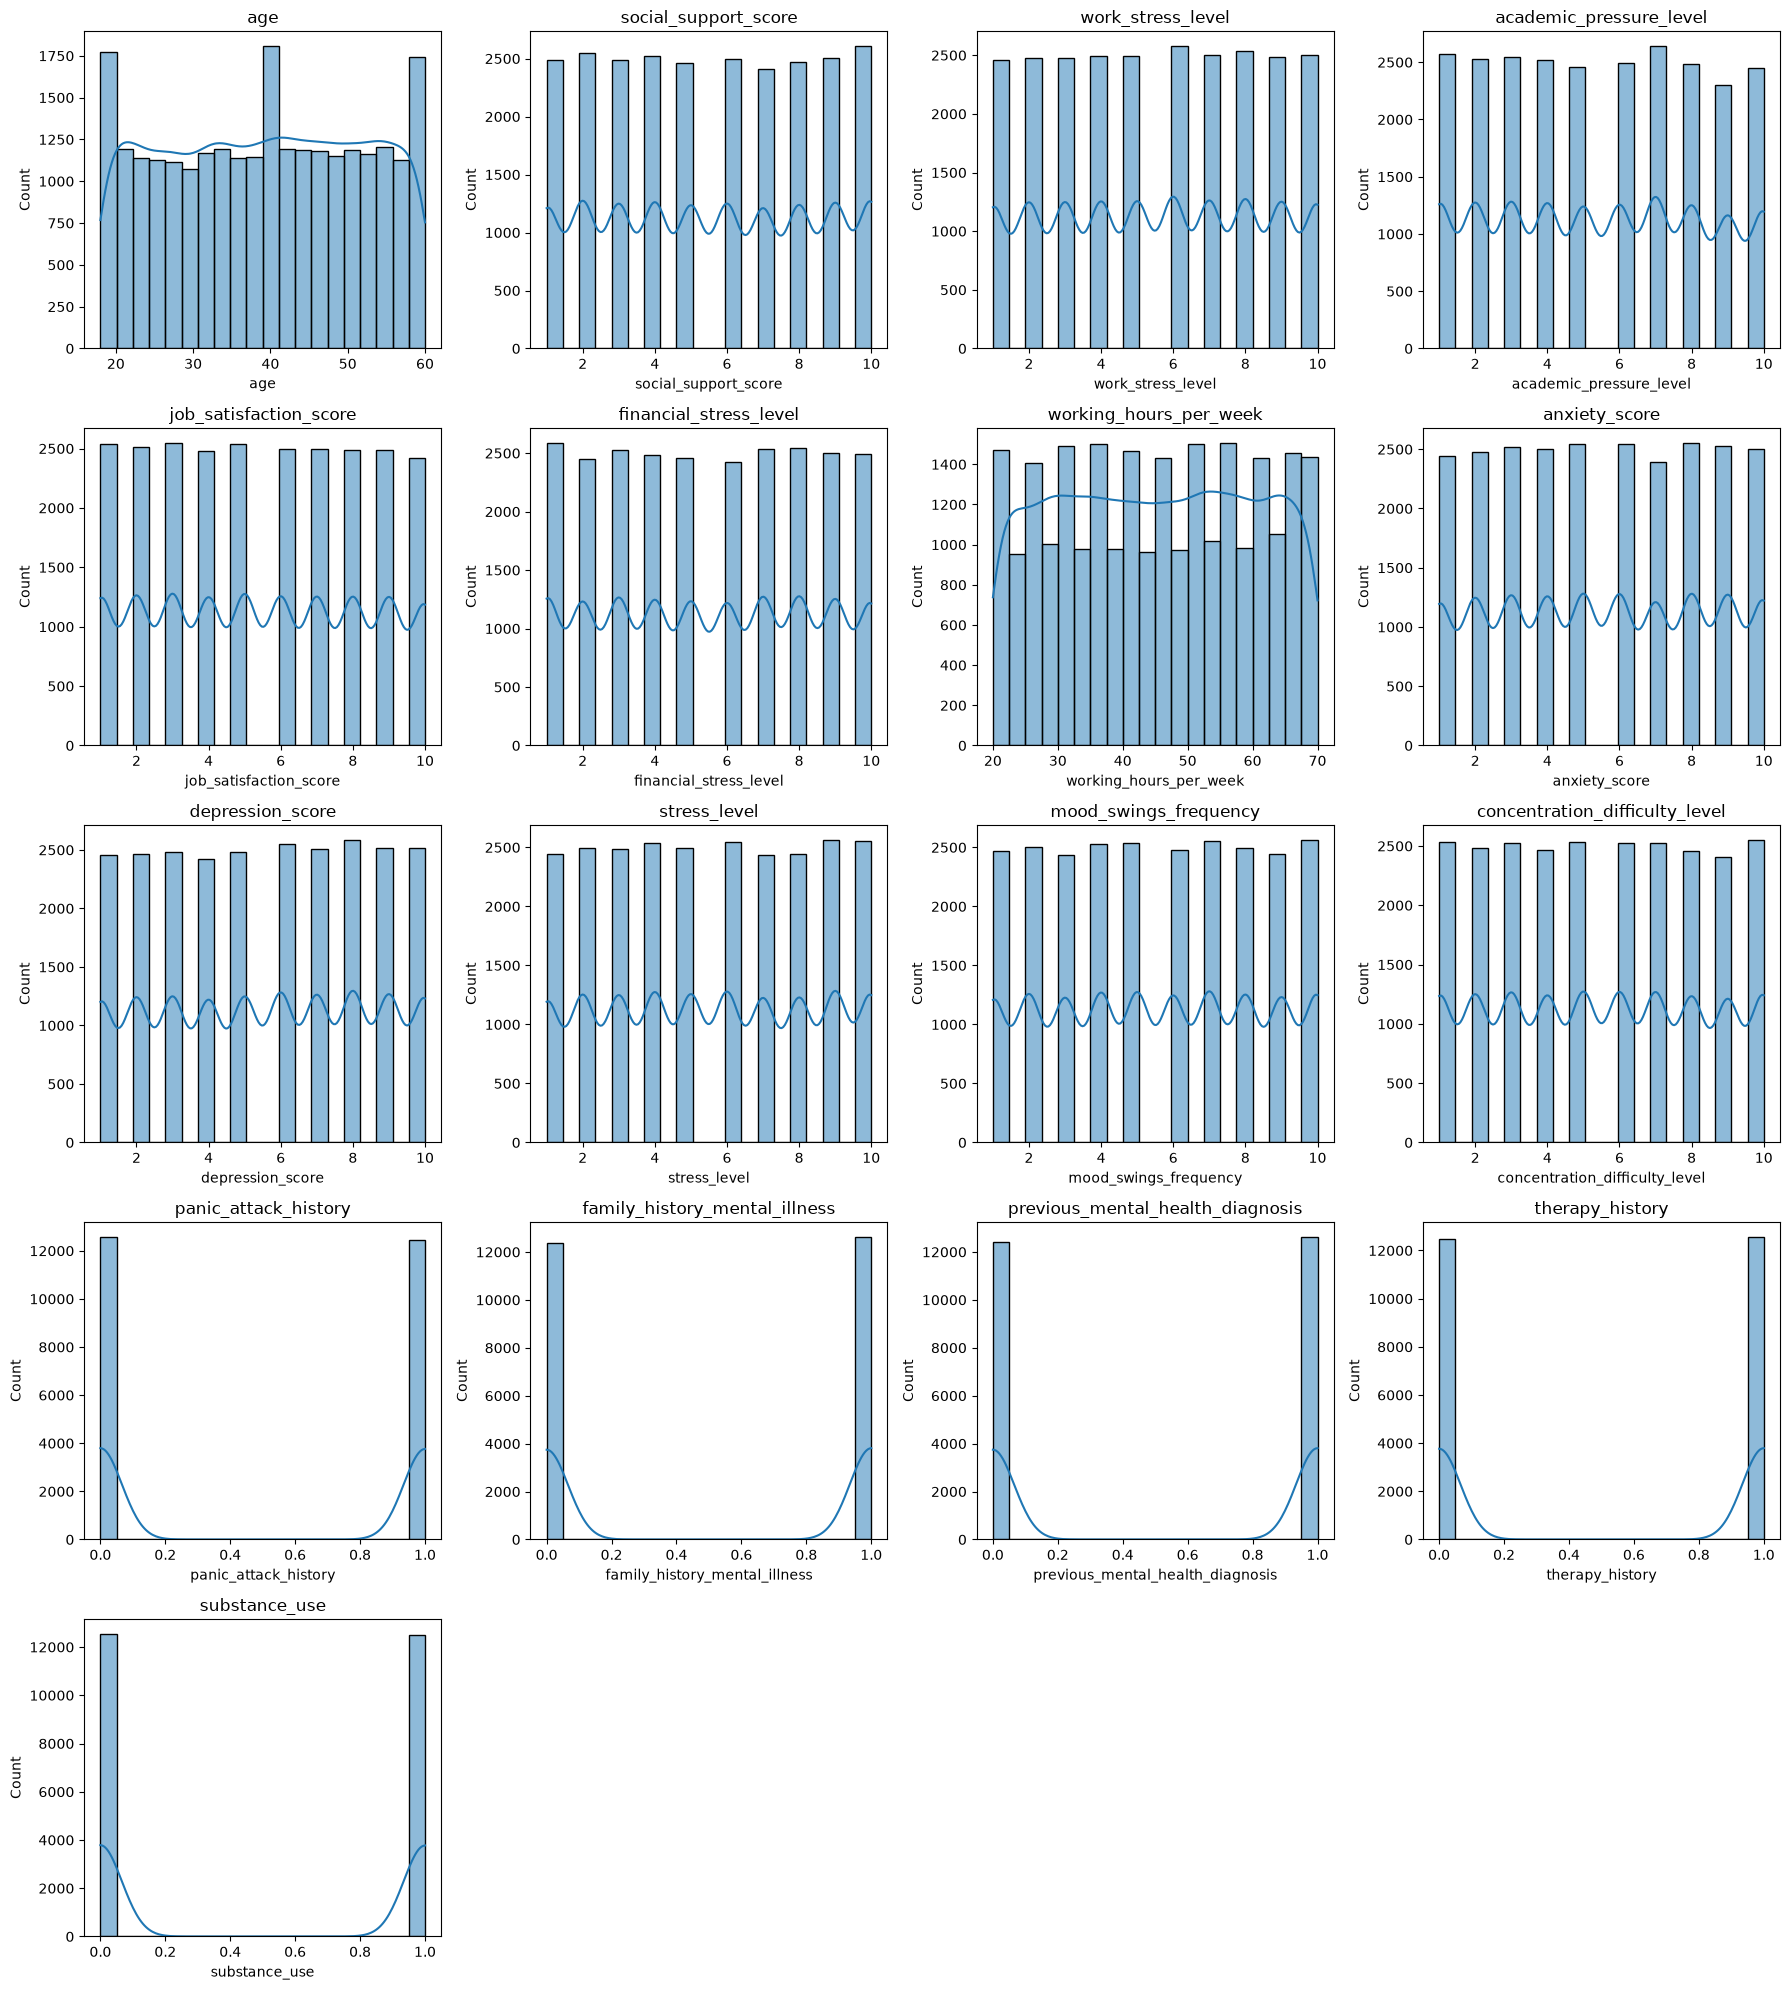

In [20]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(col)

for i in range(len(numerical_features), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

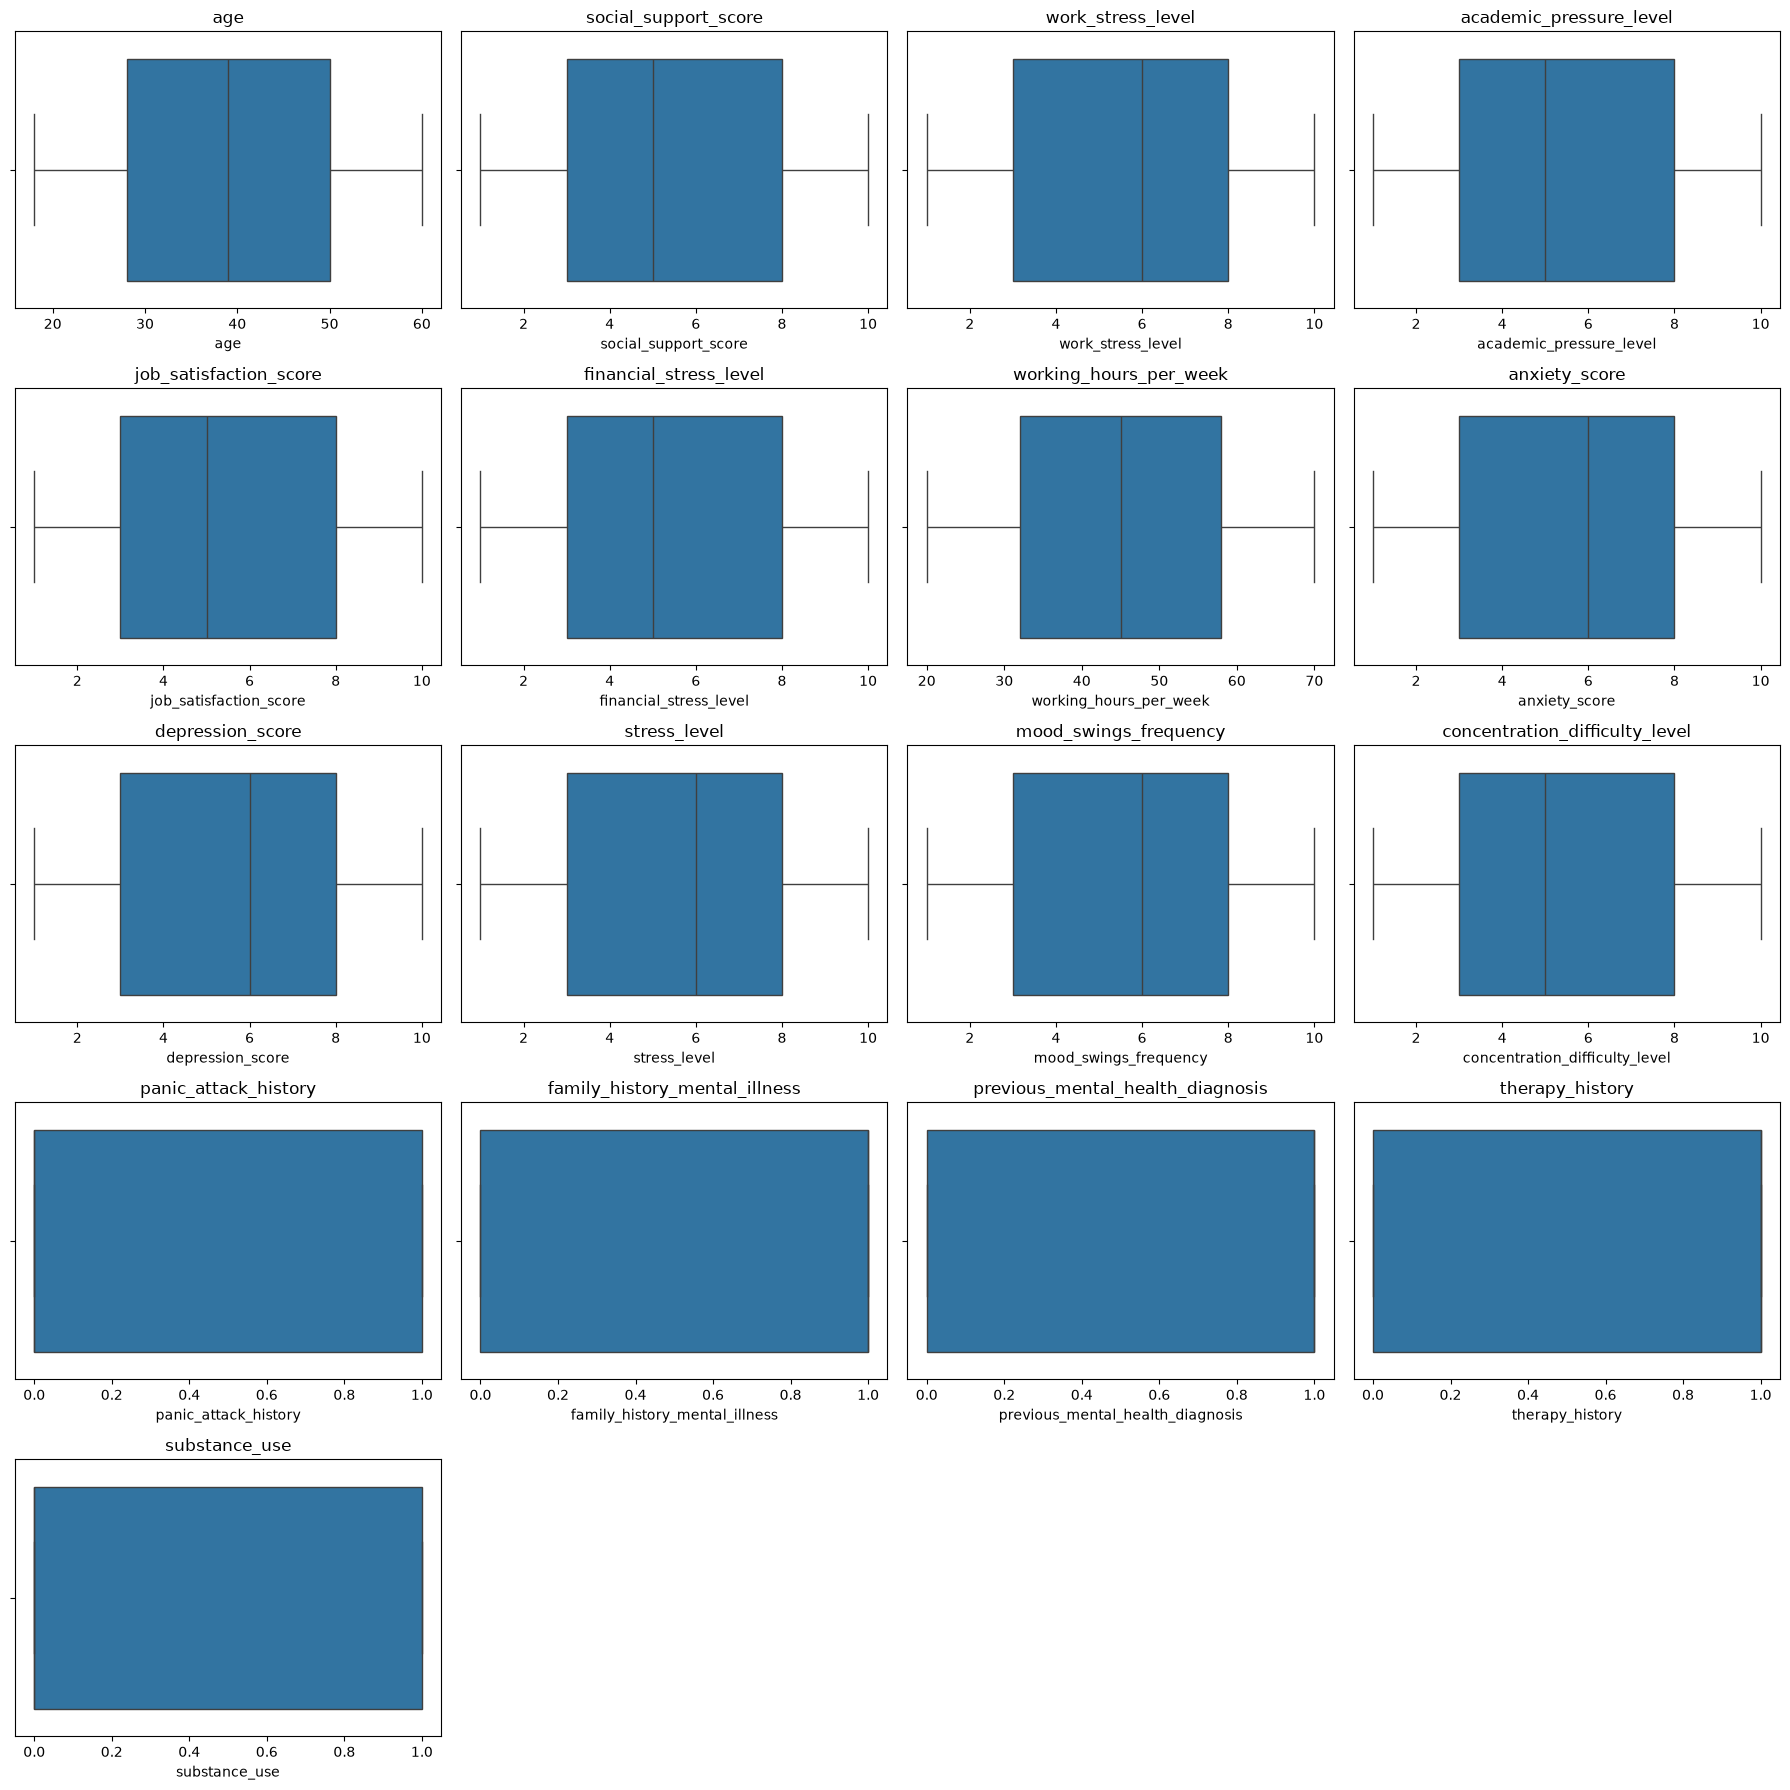

In [21]:
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for i in range(len(numerical_features), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

Univariate Analysis of Numerical Features

The numerical features were analyzed using histograms and boxplots to understand their distributions and identify potential outliers. Most features, including age, work stress level, financial stress level, anxiety score, depression score, and concentration difficulty level, exhibited approximately uniform distributions, indicating that values are evenly spread across their respective ranges. This is expected because the dataset is synthetically generated.

The boxplots revealed no significant outliers in any numerical feature. The data appeared clean, with no abnormal observations requiring removal or transformation. Binary variables such as panic attack history, therapy history, family history of mental illness, previous mental health diagnosis, and substance use contained only values 0 and 1, making them valid binary features suitable for machine learning. Overall, the numerical data is well structured and does not require additional cleaning before further analysis.

##### Univariate for the Categorical Column

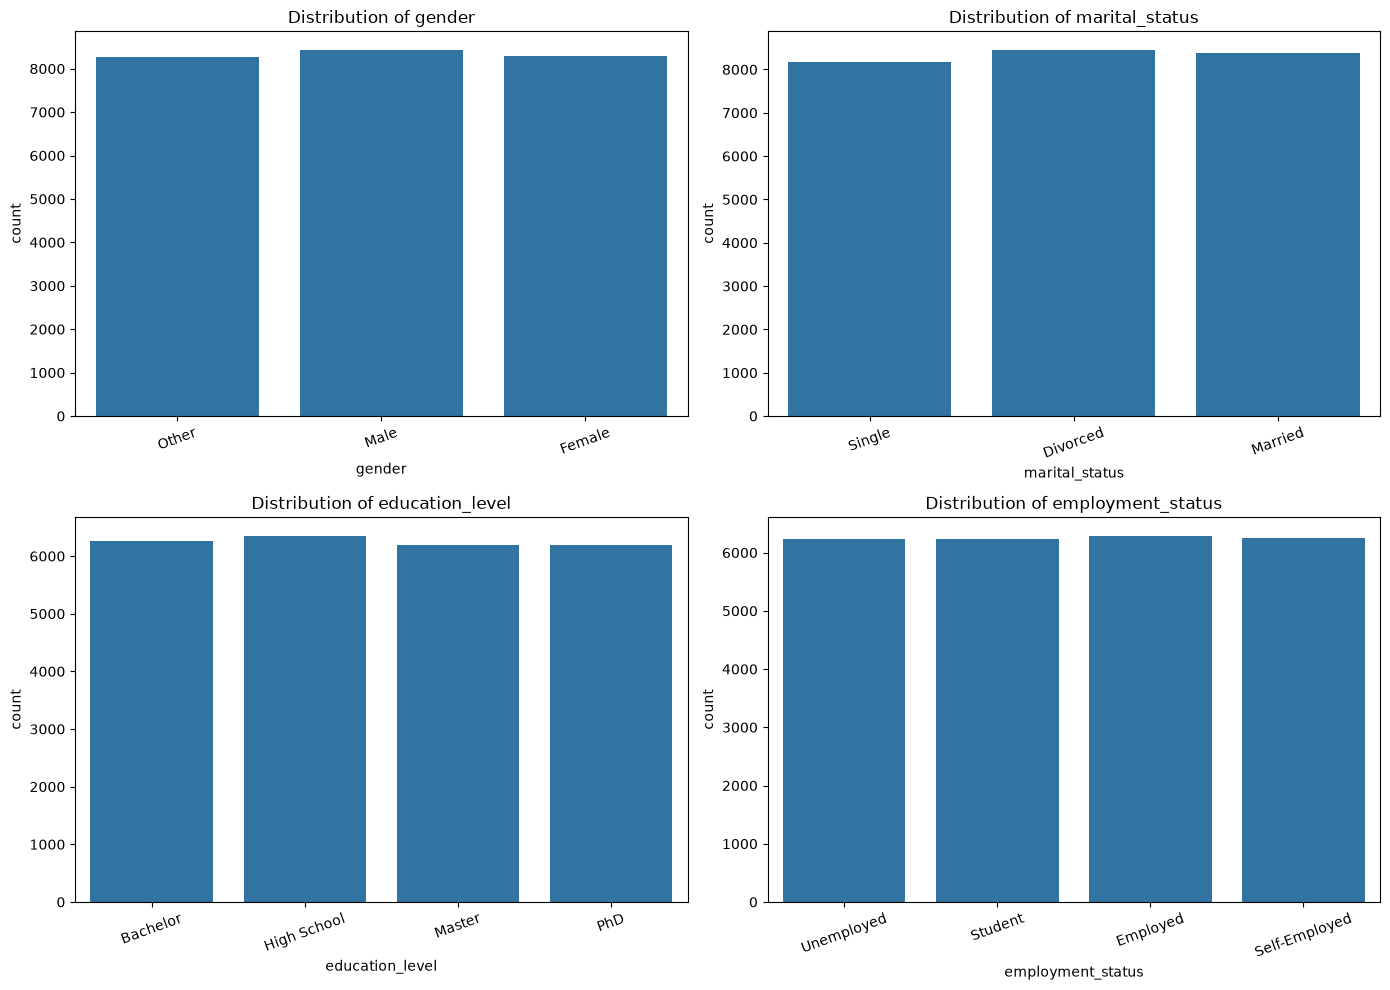

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

##### Univariate for the Targeted Column

C:\Users\Shaqeb\AppData\Local\Temp\ipykernel_20884\2842394650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


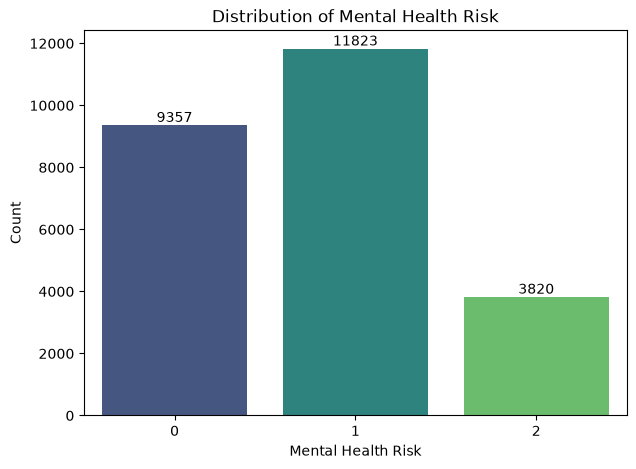

In [23]:
plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df,
    x='mental_health_risk',
    palette='viridis'
)
plt.title("Distribution of Mental Health Risk")
plt.xlabel("Mental Health Risk")
plt.ylabel("Count")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Target Variable Analysis

The target variable mental_health_risk consists of three classes representing Low Risk (0), Moderate Risk (1), and High Risk (2). The distribution shows that approximately 47.29% of the individuals belong to the Moderate Risk category, 37.43% belong to the Low Risk category, and 15.28% belong to the High Risk category.

The dataset exhibits a moderate class imbalance, as the High Risk class contains fewer observations compared to the other two classes. However, the imbalance is not severe enough to require immediate corrective measures. The effect of this imbalance will be evaluated later using model performance metrics such as Precision, Recall, and F1-score.

In [24]:
lifestyle_features = [
    'sleep_hours',
    'physical_activity_hours_per_week',
    'screen_time_hours_per_day',
    'social_support_score',
    'work_stress_level',
    'financial_stress_level'
]

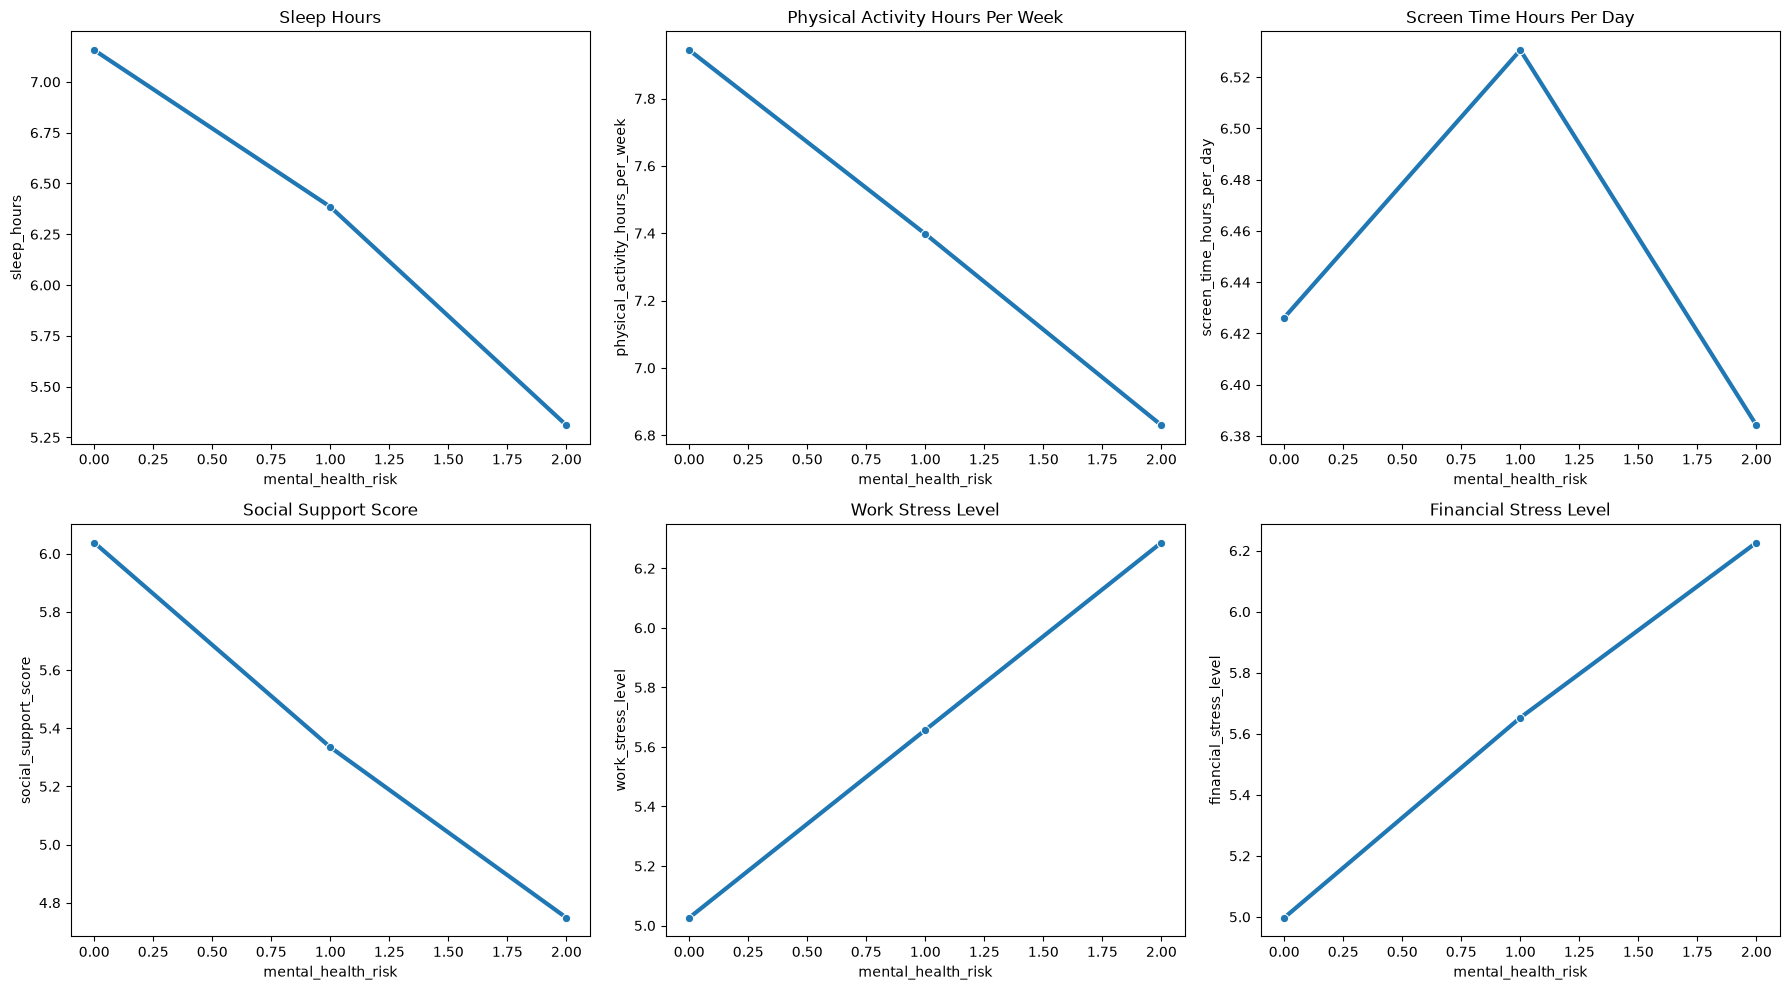

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(lifestyle_features):

    trend = (
        df.groupby('mental_health_risk')[col]
          .mean()
          .reset_index()
    )

    sns.lineplot(
        data=trend,
        x='mental_health_risk',
        y=col,
        marker='o',
        linewidth=3,
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_"," ").title())

plt.tight_layout()
plt.show()

Sleep is the superhero - It's connected to ALL good habits

Exercise is the sidekick - It makes everything better

Work stress is the villain - It breaks everything

Friends and family protect you - Social support keeps you healthy

Too much screen time is harmful - It replaces healthy activities

##### Checking the Correlation with the target column

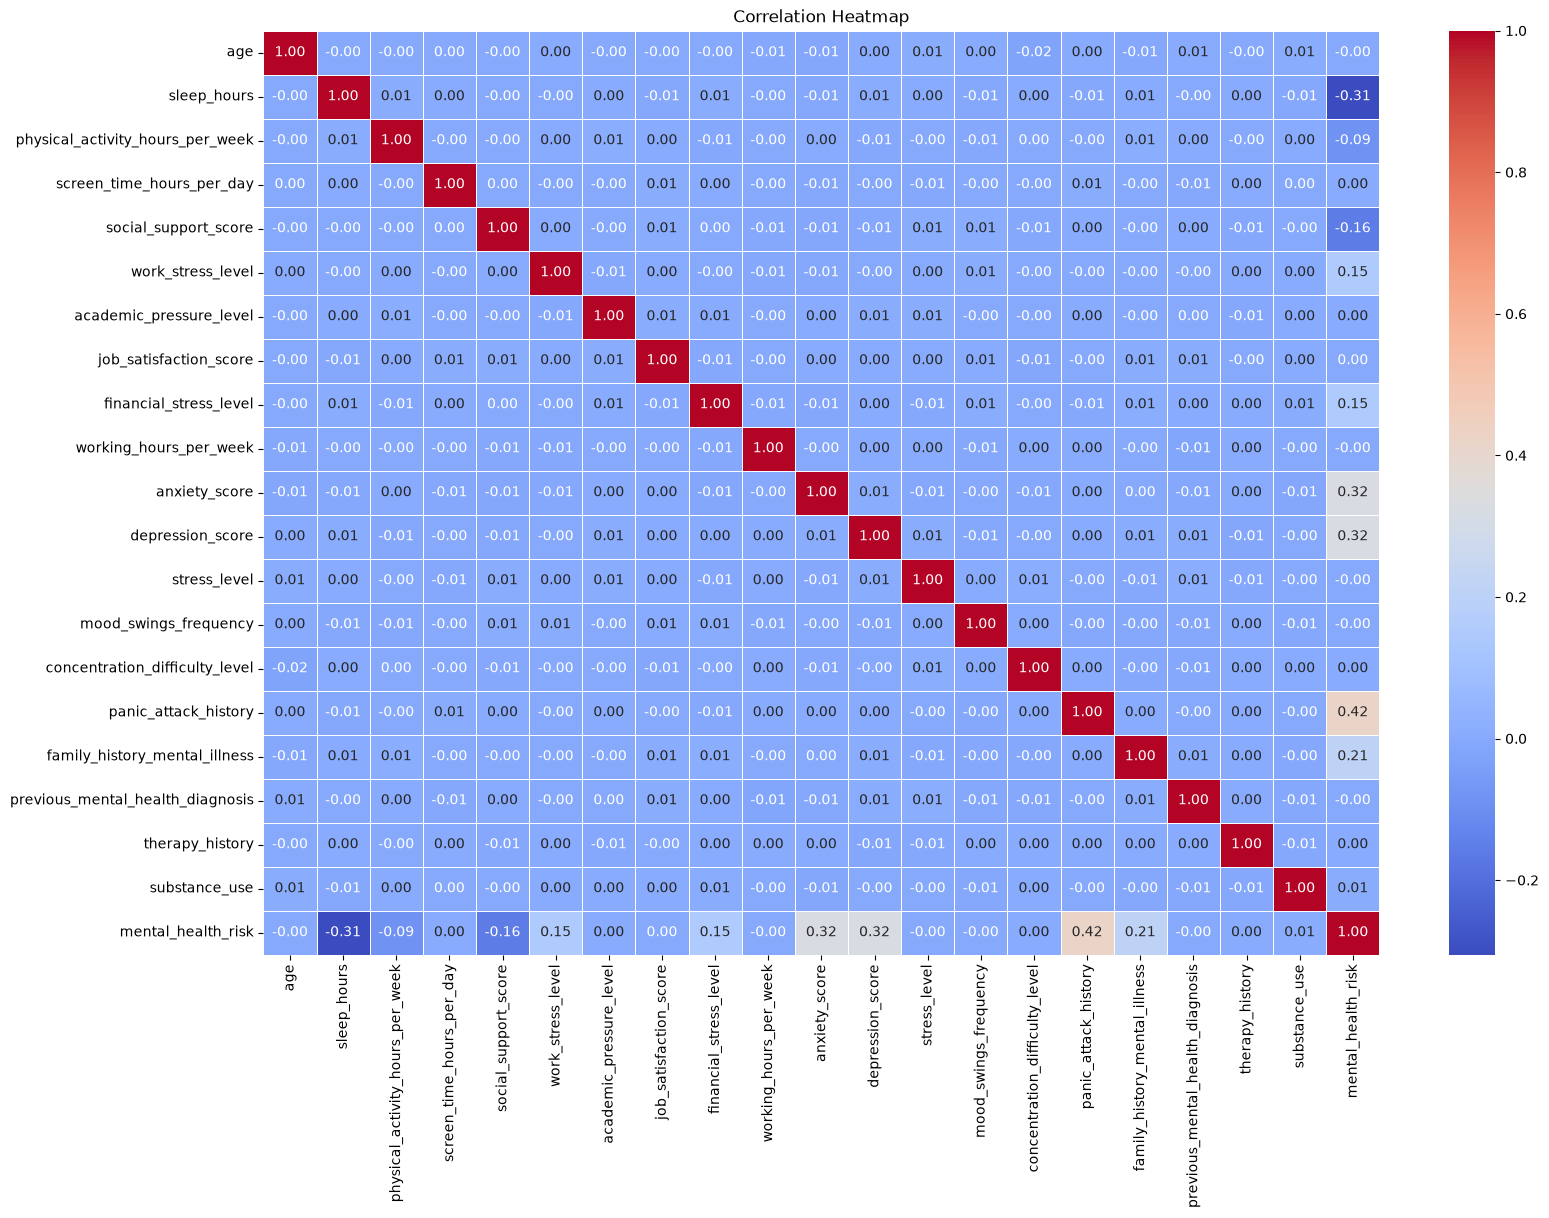

In [26]:
plt.figure(figsize=(18, 12))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [27]:
target_corr = (
    corr_matrix["mental_health_risk"]
    .sort_values(ascending=False)
)

print(target_corr)

mental_health_risk                  1.000000
panic_attack_history                0.422517
anxiety_score                       0.323683
depression_score                    0.321500
family_history_mental_illness       0.208768
work_stress_level                   0.152105
financial_stress_level              0.149601
substance_use                       0.006668
academic_pressure_level             0.004481
concentration_difficulty_level      0.002001
screen_time_hours_per_day           0.001415
therapy_history                     0.000761
job_satisfaction_score              0.000548
stress_level                       -0.000284
working_hours_per_week             -0.001168
age                                -0.002855
previous_mental_health_diagnosis   -0.003641
mood_swings_frequency              -0.004075
physical_activity_hours_per_week   -0.088692
social_support_score               -0.157517
sleep_hours                        -0.305238
Name: mental_health_risk, dtype: float64


##### Train - Test Split 

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['mental_health_risk'])
y = df['mental_health_risk']

X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [30]:
preprocessor = ColumnTransformer (
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features
        ),

        (
            'cat',
            OneHotEncoder(handle_unknown = 'ignore'),
            categorical_features
        ),

        (
            'bin',
            'passthrough',
            binary_features
        )
    ]
)

In [31]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [32]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_pipeline = Pipeline(
    steps = [
        ('preprocessor' , preprocessor),
        ('classifier' , RandomForestClassifier(random_state = 42))
    ]
)

In [34]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](3,)","[0,1,2]"
feature_names_in_,"ndarray[object](24,)","['age','gender','marital_status',...,'previous_mental_health_diagnosis', 'therapy_history','substance_use']"
n_features_in_,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [35]:
y_pred = rf_pipeline.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9626


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1871
           1       0.93      0.99      0.96      2365
           2       1.00      0.79      0.88       764

    accuracy                           0.96      5000
   macro avg       0.97      0.93      0.95      5000
weighted avg       0.96      0.96      0.96      5000



In [39]:
print(confusion_matrix(y_test, y_pred))

[[1863    8    0]
 [  20 2344    1]
 [   0  158  606]]


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [41]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    )

}

In [42]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({

        'Model': name,

        'Accuracy': accuracy_score(y_test, y_pred),

        'Precision': precision_score(
            y_test,
            y_pred,
            average='weighted'
        ),

        'Recall': recall_score(
            y_test,
            y_pred,
            average='weighted'
        ),

        'F1 Score': f1_score(
            y_test,
            y_pred,
            average='weighted'
        )

    })

In [43]:
result_df = pd.DataFrame(results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7504,0.752959,0.7504,0.749878
1,Decision Tree,0.9910,0.991002,0.9910,0.990999
2,Random Forest,0.9626,0.964492,0.9626,0.961344
3,XGBoost,0.9988,0.998803,0.9988,0.998798


In [44]:
result_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

result_df

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.9988,0.998803,0.9988,0.998798
1,Decision Tree,0.9910,0.991002,0.9910,0.990999
2,Random Forest,0.9626,0.964492,0.9626,0.961344
0,Logistic Regression,0.7504,0.752959,0.7504,0.749878


In [45]:
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(train_accuracy)
print(test_accuracy)

1.0
0.9988


In [46]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=pipeline,
    X=X,
    y=y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.999  0.9988 0.9984 0.999  0.9978]
Mean CV Accuracy: 0.9986
Standard Deviation: 0.0004560701700396537


#### Hyperparamter Tuning

In [47]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            random_state=42,
            eval_metric='mlogloss'
        ))
    ]
)

In [48]:
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [49]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator = xgb_pipeline,
    param_distributions = param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [50]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best es

In [51]:
print(random_search.best_params_)

{'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}


In [52]:
print(random_search.best_score_)

0.9971


In [53]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9988
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1871
           1       1.00      1.00      1.00      2365
           2       1.00      0.99      1.00       764

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [54]:
import shap
print(shap.__version__)

0.52.0


c:\Depression_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
best_pipeline = random_search.best_estimator_

In [70]:
preprocessor = best_pipeline.named_steps["preprocessor"]
model = best_pipeline.named_steps["classifier"]

In [71]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

In [73]:
X_train_transformed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

In [ ]:
explainer = shap.TreeExplainer(model)

In [75]:
shap_values = explainer(X_test_transformed)

In [76]:
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(5000, 34, 3)


#### SHAP Summary Plot - Explainable AI

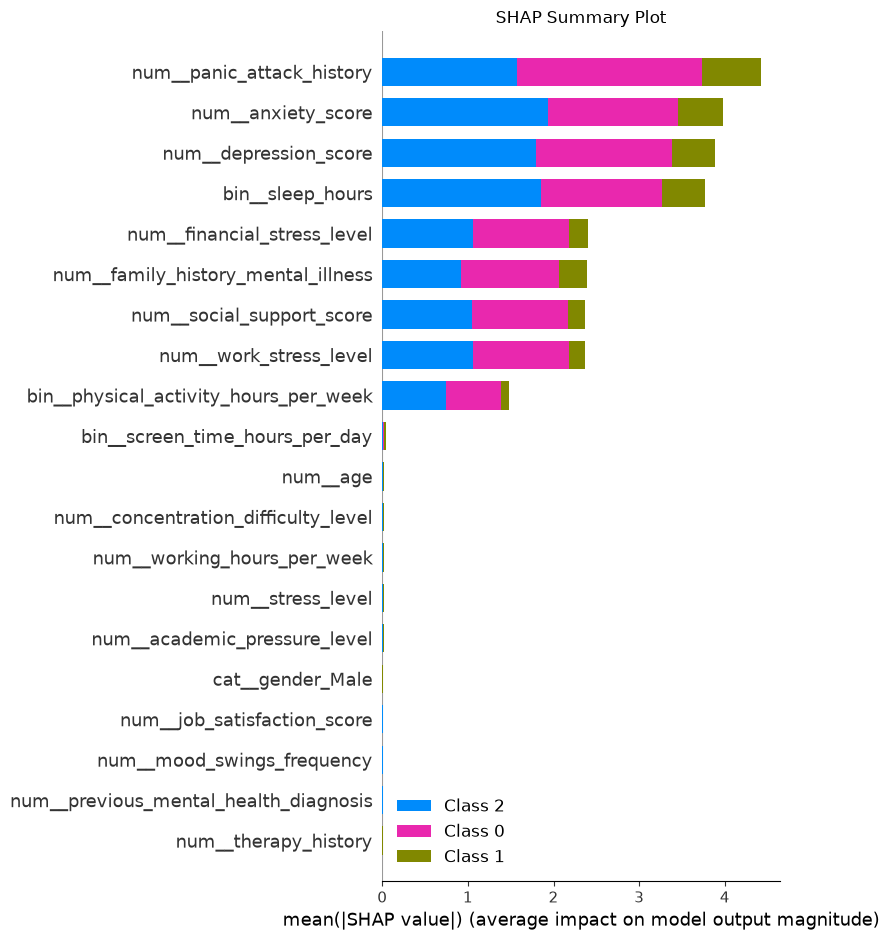

In [77]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test_transformed,
    show=False
)

plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

SHAP analysis revealed that Panic Attack History, Anxiety Score, Depression Score, Sleep Hours, and Financial Stress Level were the most influential features affecting mental health risk predictions. In contrast, variables such as Therapy History, Previous Mental Health Diagnosis, Age, and Gender had minimal impact on the model's decisions. These findings indicate that the model primarily relies on psychological and lifestyle-related factors rather than demographic attributes.

In [83]:
prediction = model.predict(X_test_transformed)

print(prediction[0])

1


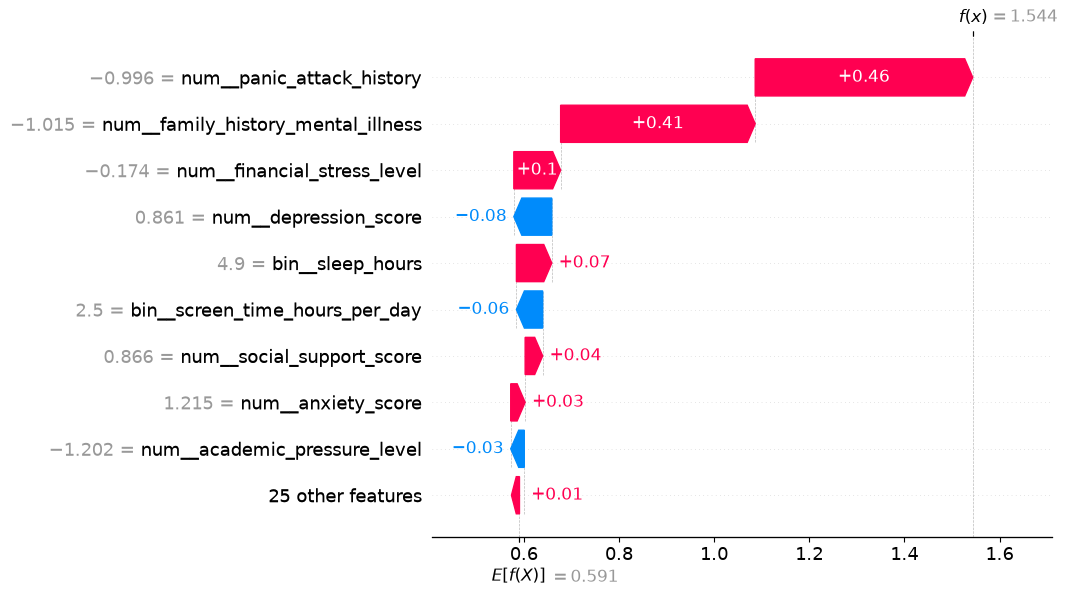

In [84]:
predicted_class = prediction[0]

shap.plots.waterfall(
    shap_values[0, :, predicted_class],
    max_display=10
)